# Faraday

This tutorial explains how Faraday works and how to use Faraday to train a generative model and generate synthetic smart meter data.

---

Faraday is a Conditional Variational Auto-Encoder (VAE)-based model. Unlike traditional VAEs where seeds are drawn from a normal distribution and decoded, Faraday works by:
1. First train a VAE using the following loss functions: a. MMD instead of KL-divergence b. Quantile losses and c. Mean squared error
2. Encode real samples to the latent space using the encoder, and fit a Gaussian Mixture Model (GMM) over the latent space.
3. During inference, draw samples from the GMM and decode with the decoder.

For more information on Faraday's architecture, refer to the [Faraday paper](https://arxiv.org/abs/2404.04314).


### Pre-requisites

If you haven't already, please download LCL dataset from [data.london.gov.uk](https://data.london.gov.uk/dataset/smartmeter-energy-use-data-in-london-households). 


In [1]:
import pandas as pd

from opensynth.data_modules.goiener_data_module import GoiEnerDataModule
%load_ext autoreload
%autoreload 2

In [2]:
import os

import sys

import logging

logger = logging.getLogger(__name__)

# 💿 Loading GoiEner Data

In [3]:
from pathlib import Path
from opensynth.data_modules.goiener_data_module import GoiEnerDataModule
import pytorch_lightning as pl

import matplotlib.pyplot as plt

data_path = Path("../../data/processed/goiener/historical/train/goiener_data.csv")
stats_path = Path("../../data/processed/goiener/historical/train/mean_std.csv")
outlier_path = Path("../../data/processed/goiener/historical/train/outliers.csv")

dm = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=25000, n_samples=100000)
dm.setup()

In [4]:
dm_with_outliers = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=200, n_samples=20000, outlier_path=outlier_path)
dm_with_outliers.setup()

# 🤖 VAE Module

In [5]:
from opensynth.models.faraday.vae_model import FaradayVAE
# Option to pass in your own encoder architecture in the future
model = FaradayVAE(class_dim=2, latent_dim=16, learning_rate=0.001, mse_weight=3)

In [6]:
# Batch size 500 is when MPS becomes faster than CPU..
# But sometimes large batch size hurts convergence..
# Suggest training on CPU with small batch size
# And potentially experiment with best hyperparameters on large batch size before using 'mps'

trainer = pl.Trainer(max_epochs=150, accelerator="auto")
trainer.fit(model, dm_with_outliers)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name           | Type                    | Params | Mode 
-------------------------------------------------------------------
0 | encoder        | Encoder           

Epoch 149: 100%|██████████| 100/100 [00:02<00:00, 34.46it/s, v_num=34, total_loss=0.885, mmd_loss=0.00871, mse_loss=0.254, quantile_loss=0.622]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 149: 100%|██████████| 100/100 [00:02<00:00, 34.04it/s, v_num=34, total_loss=0.885, mmd_loss=0.00871, mse_loss=0.254, quantile_loss=0.622]


In [7]:
import torch
torch.save(model, "goiener_vae_model.pt")

# 🕸️ GMM Module

In [8]:
from opensynth.models.faraday.model import FaradayModel
import numpy as np
import torch

In [9]:
# torch.save(model, "faraday_model.pt")
model = torch.load("goiener_vae_model.pt", weights_only=False)

Need to update model s.t. `feature_list` is saved if want to load model from checkpoint. For now, use trained VAE.

In [12]:
faraday_model_150 = FaradayModel(
    vae_module=model, n_components=150, tol=1e-3, max_epochs=100, covariance_reg=1e-4,
)

faraday_model_50 = FaradayModel(
    vae_module=model, n_components=50, tol=1e-3, max_epochs=100, covariance_reg=1e-4,
)


faraday_model_10 = FaradayModel(
    vae_module=model, n_components=10, tol=1e-3, max_epochs=100, covariance_reg=1e-4,
)

In [13]:
gmm_data_module = GoiEnerDataModule(data_path=data_path, stats_path=stats_path, batch_size=2000, n_samples=8000, outlier_path=outlier_path)
gmm_data_module.setup()

In [14]:
faraday_model_10.train_gmm(dm=gmm_data_module)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name                      | Type                        | Params | Mode 
----------------------------------------------------------------------------------
0 | gmm_module                | GaussianMixtureModel        | 0      | train
1 | vae_module                | FaradayVAE                  | 402 K  | train
2 | weight

Initial prec chol: 0.8073898553848267.                 Initial mean: 0.3377045691013336
Epoch 7: 100%|██████████| 4/4 [00:00<00:00, 34.03it/s, v_num=35]


In [15]:
faraday_model_50.train_gmm(dm=gmm_data_module)

Initial prec chol: 0.97297203540802.                 Initial mean: -0.0482790470123291


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name                      | Type                        | Params | Mode 
----------------------------------------------------------------------------------
0 | gmm_module                | GaussianMixtureModel        | 0      | train
1 | vae_module                | FaradayVAE                  | 402 K  | train
2 | weight

Epoch 4: 100%|██████████| 4/4 [00:00<00:00, 22.29it/s, v_num=36]


In [16]:
faraday_model_150.train_gmm(dm=gmm_data_module)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/hajalibayram/phd/dev/OpenSynth/.venv/lib/python3.13/site-packages/pytorch_lightning/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name                      | Type                        | Params | Mode 
----------------------------------------------------------------------------------
0 | gmm_module                | GaussianMixtureModel        | 0      | train
1 | vae_module                | FaradayVAE                  | 402 K  | train
2 | weight

Initial prec chol: 0.8025625944137573.                 Initial mean: -0.725919783115387
Epoch 2: 100%|██████████| 4/4 [00:00<00:00, 12.75it/s, v_num=37]


In [17]:
# Check number of components with zero means

ligthning_sum_components = faraday_model_10.gmm_module.means.sum(axis=1)
faraday_model_10_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

ligthning_sum_components = faraday_model_50.gmm_module.means.sum(axis=1)
faraday_model_50_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

ligthning_sum_components = faraday_model_150.gmm_module.means.sum(axis=1)
faraday_model_150_zero_means = len(ligthning_sum_components[ligthning_sum_components==0])

faraday_model_10_zero_means, faraday_model_50_zero_means, faraday_model_150_zero_means

(6, 38, 131)

In [19]:
torch.save(faraday_model_150, "goiener_faraday_model_150.pt")
torch.save(faraday_model_50, "goiener_faraday_model_50.pt")
torch.save(faraday_model_10, "goiener_faraday_model_10.pt")

# 📈 Comparing Results

### 0. Generating Samples

In [20]:
def generate_synthetic_samples(model, n_samples, dm):
    gmm_samples = model.sample_gmm(n_samples)
    gmm_samples_reconstructed = dm.reconstruct_kwh(gmm_samples['kwh'])
    gmm_samples_reconstructed = torch.clip(gmm_samples_reconstructed, min=0)
    return gmm_samples_reconstructed

In [21]:
gmm_150 = generate_synthetic_samples(faraday_model_150, 20000, dm)
gmm_50 = generate_synthetic_samples(faraday_model_50, 20000, dm)
gmm_10 = generate_synthetic_samples(faraday_model_10, 20000, dm=dm)

In [22]:
real_kwh = dm.reconstruct_kwh(next(iter(gmm_data_module.train_dataloader()))['kwh'])
real_kwh = torch.clip(real_kwh, min=0) # Clip min 0 to get read of negative values

### 1. Comparing mean, 95th quantile, median profiles

In [23]:
def plot_stats(real_kwh, gmm_reconstruct):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 3), sharey=True, gridspec_kw={'wspace': 0.05})

    ax1.plot(real_kwh.mean(dim=0).detach().numpy(), label="real kwh")
    ax1.plot(gmm_reconstruct.mean(dim=0).detach().numpy(), label="gmm kwh")
    ax1.set_title("Mean kWh per half hour")
    ax1.set_xlabel("Settlement Periods")
    ax1.legend()

    ax2.plot(real_kwh.quantile(0.95, dim=0).detach().numpy(), label="real kwh")
    ax2.plot(gmm_reconstruct.quantile(0.95, dim=0).detach().numpy(), label="gmm kwh")
    ax2.set_title("95th Quantile kWh per half hour")
    ax2.set_xlabel("Settlement Periods")
    ax2.legend()

    ax3.plot(real_kwh.quantile(0.5, dim=0).detach().numpy(), label="real kwh")
    ax3.set_title("Median kWh per half hour")
    ax3.set_xlabel("Settlement Periods")
    ax3.plot(gmm_reconstruct.quantile(0.5, dim=0).detach().numpy(), label="gmm kwh")
    ax3.legend()

    fig.text(0.1, 0.5, 'kWh', va='center', rotation='vertical')

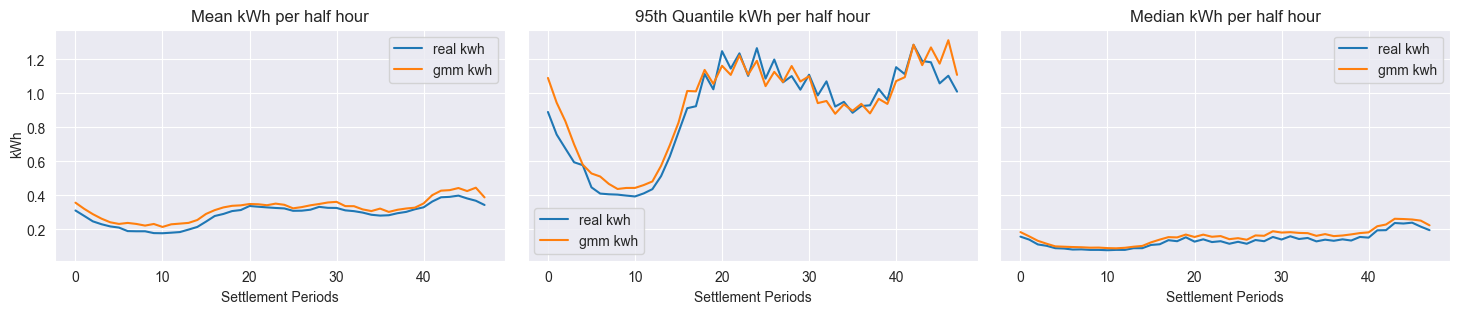

In [24]:
plot_stats(real_kwh, gmm_150)

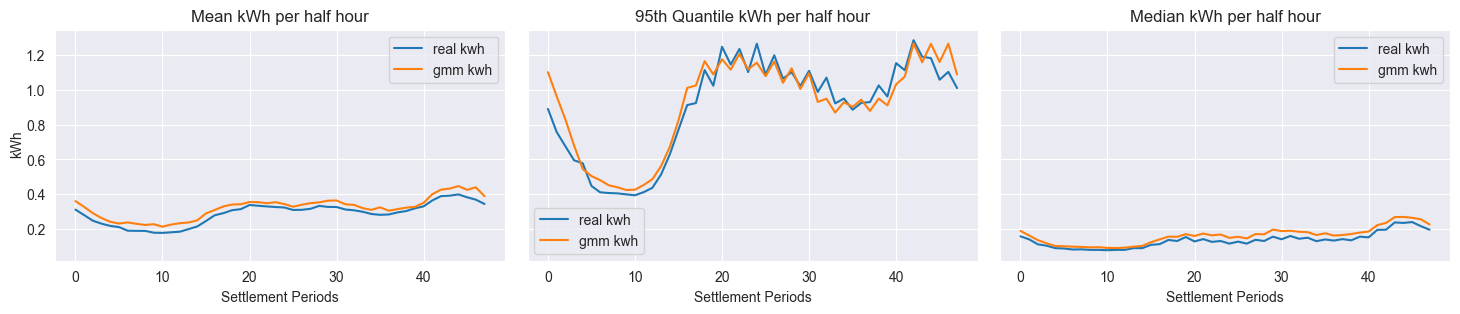

In [25]:
plot_stats(real_kwh, gmm_50)

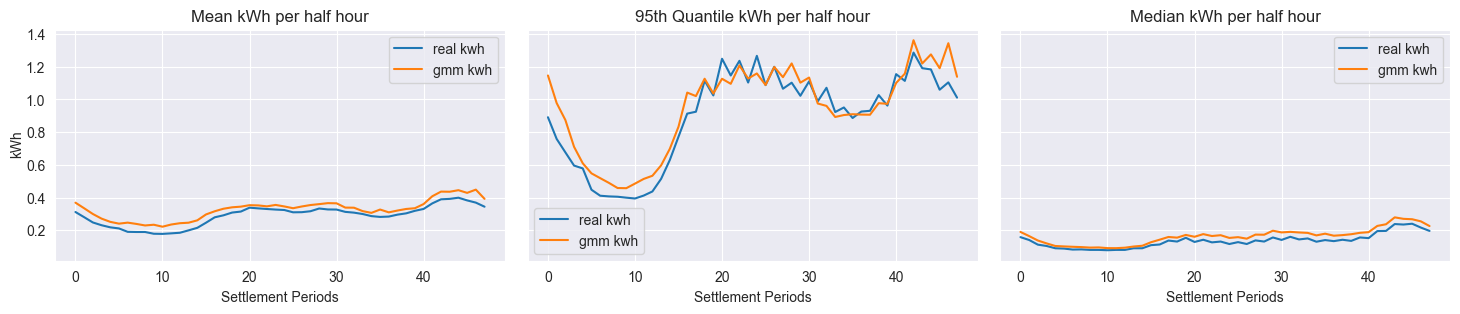

In [26]:
plot_stats(real_kwh, gmm_10)

### 2. PCA and TSNE Distribution Plots

In [27]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np


def train_pca_and_tsne(real_kwh, gmm_reconstruct):
    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2)

    pca.fit(real_kwh.detach().numpy())
    pca_real = pca.transform(real_kwh.detach().numpy())
    pca_gmm = pca.transform(gmm_reconstruct.detach().numpy())

    tsne_input = np.concatenate([real_kwh.detach().numpy(), gmm_reconstruct.detach().numpy()])
    tsne_results = tsne.fit_transform(tsne_input)
    tsne_real = tsne_results[:len(real_kwh)]
    tsne_gmm = tsne_results[len(real_kwh):]

    return pca_real, pca_gmm, tsne_real, tsne_gmm


def plot_pca_tsne(pca_real, pca_gmm, tsne_real, tsne_gmm):
    fig, (ax_pca, ax_tsne) = plt.subplots(1, 2, figsize=(12, 4))

    ax_pca.scatter(pca_real[:, 0], pca_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_pca.scatter(pca_gmm[:, 0], pca_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_pca.set_title("PCA")
    ax_pca.set_xlabel("PCA 1")
    ax_pca.set_ylabel("PCA 2")
    ax_pca.legend()

    ax_tsne.scatter(tsne_real[:, 0], tsne_real[:, 1], label="real kwh", s=0.3, alpha=0.5)
    ax_tsne.scatter(tsne_gmm[:, 0], tsne_gmm[:, 1], label="gmm kwh", s=0.3, alpha=0.5)
    ax_tsne.set_title("TSNE")
    ax_tsne.set_xlabel("TSNE 1")
    ax_tsne.set_ylabel("TSNE 2")
    ax_tsne.legend()
    return fig


Text(0.5, 1.0, 'GMM with 150 clusters')

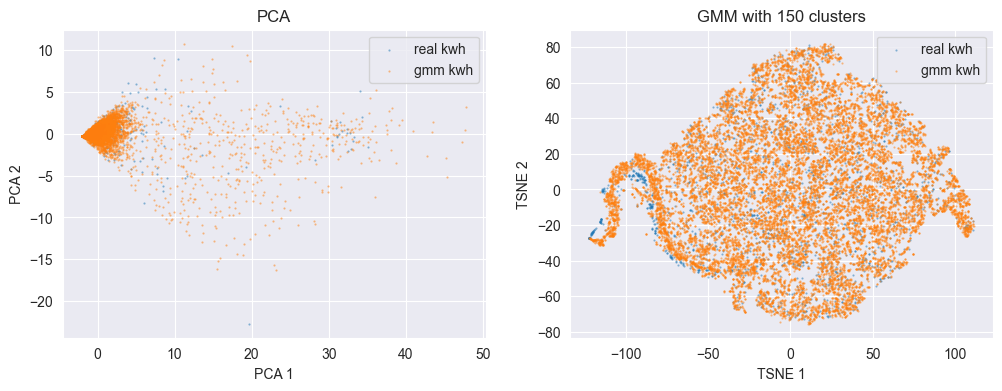

In [28]:
b1, b2, b3, b4 = train_pca_and_tsne(real_kwh, gmm_150)
_ = plot_pca_tsne(b1, b2, b3, b4)
plt.title("GMM with 150 clusters")

Text(0.5, 1.0, 'GMM with 50 clusters')

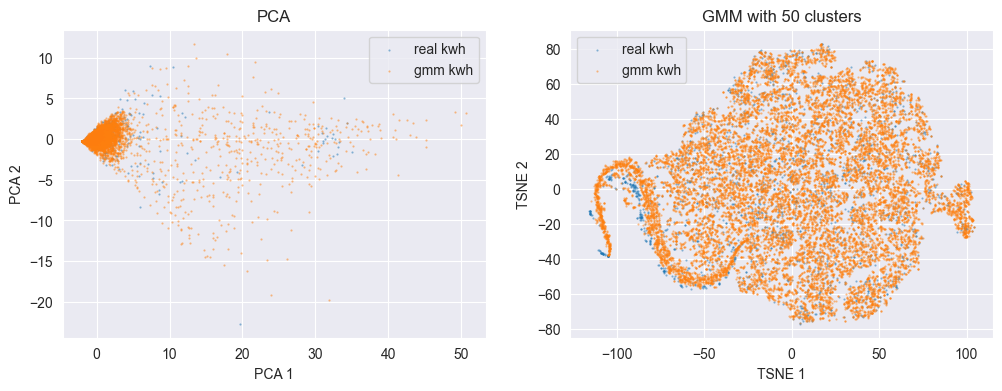

In [29]:
c1, c2, c3, c4 = train_pca_and_tsne(real_kwh, gmm_50)
_ = plot_pca_tsne(c1, c2, c3, c4)
plt.title("GMM with 50 clusters")

Text(0.5, 1.0, 'GMM with 10 clusters')

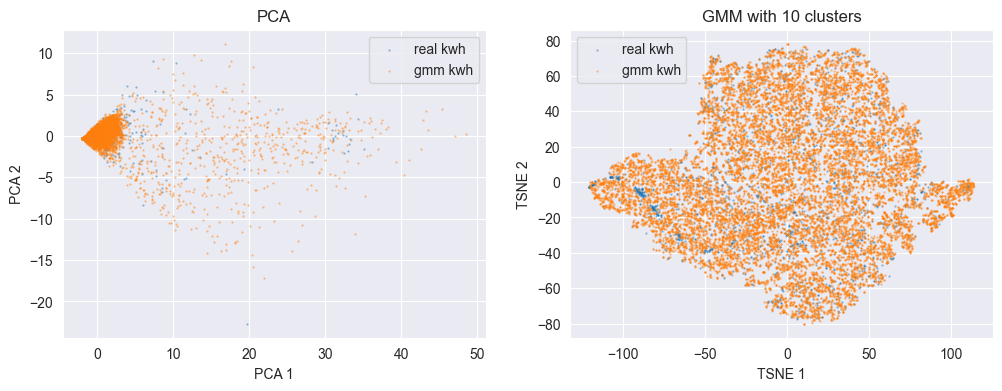

In [30]:
d1, d2, d3, d4 = train_pca_and_tsne(real_kwh, gmm_10)
_ = plot_pca_tsne(d1, d2, d3, d4)
plt.title("GMM with 10 clusters")

# 🛃 Customising your VAE Architecture

It's possible to also customise your VAE archicture without touching the rest of Faraday code. You can do this by:

1. Creating a custom class inheriting from the Encoder and Decoder module
2. Using `super().__init__()` to inherit all the attributes and methods of the parent class
3. Overriding the attribute `encoder_layers` or `decoder_layers`. 

In this example, we'll be showing how to do this with simple linear layers, but in reality you could use more complicated architectures such as Conv1D layers, or LSTM layers.
For more complex layers, you'll need to make sure that you've shaped the inputs correctly.

In [29]:
from opensynth.models.faraday.vae_model import FaradayVAE, Encoder, Decoder
from opensynth.models.faraday.model import FaradayModel
import torch.nn as nn
import torch

### Create Custom Encoder and Decoder Architectures.

In [ ]:
class CustomEncoderModule(Encoder):
    """
    Custom Encoder Module
    """
    def __init__(self, latent_dim: int, input_dim: int, class_dim: int):
        """
        Inherit parent encoder attributes and methods.
        But we will be overriding the `encoder_layers` attribute
        with our custom encoder architecture.

        When inheriting from parent `Encoder` class, we need to
        pass in the attributes: latent_dim, input_dim, class_dim.

        Outputs of encoder_layers should be `latent_dim`.

        Args:
            latent_dim (int): Latent dimension.
            input_dim (int): Input dimensions.
            class_dim (int): Class dimensions.
        """
        super().__init__(latent_dim=latent_dim, input_dim=input_dim, class_dim=class_dim)
        self.encoder_layers = nn.Sequential(
            nn.Linear(self.encoder_input_dim, 1024),
            nn.GELU(),
            nn.Linear(1024, self.latent_dim)
        )


class CustomDecoderModule(Decoder):
    """
    Custom Decoder Module
    """
    def __init__(self, class_dim: int, latent_dim: int, output_dim: int):
        """
        Inherit parent decoder attributes and methods.
        But we will be overriding the `decoder_layers` attribute
        with our custom decoder architecture.

        When inheriting from parent `Decoder` class, we need to
        pass in the attributes: class_dim, latent_dim, output_dim.

        Outputs of encoder_layers should be `output_dim`.

        Args:
            latent_dim (int): Latent dimension.
            output_dim (int): Output dimensions.
            class_dim (int): Class dimensions.
        """
        super().__init__(class_dim=class_dim, latent_dim=latent_dim, output_dim=output_dim)
        self.decoder_layers = nn.Sequential(
            nn.Linear(self.latent_dim, 1024),
            nn.GELU(),
            nn.Linear(1024, self.output_dim)
        )

### Initiate Faraday VAE with custom encoder and decoders

In [ ]:
custom_encoder = CustomEncoderModule(class_dim=2, latent_dim=16, input_dim=48)
custom_decoder = CustomDecoderModule(class_dim=2, latent_dim=16, output_dim=48)

faraday_custom_vae = FaradayVAE(
    class_dim=2, 
    latent_dim=16, 
    learning_rate=0.001, 
    mse_weight=3, 
    custom_encoder=custom_encoder, 
    custom_decoder=custom_decoder
)

custom_trainer = pl.Trainer(max_epochs=250, accelerator="cpu")
custom_trainer.fit(faraday_custom_vae, dm)


In [ ]:
faraday_custom_model = FaradayModel(vae_module=faraday_custom_vae, n_components=15, tol=1e-5, gmm_covariance_reg=1e-3)
gmm_data_module = LCLDataModule(data_path=data_path, stats_path=stats_path, batch_size=5000, n_samples=50000)
gmm_data_module.setup()
faraday_custom_model.train_gmm(dm=gmm_data_module)

### Check Results

In [ ]:
custom_gmm_samples = faraday_custom_model.sample_gmm(n_samples=10000)

custom_gmm_kwh = custom_gmm_samples['kwh']
custom_gmm_reconstruct = dm.reconstruct_kwh(custom_gmm_kwh)
custom_gmm_reconstruct = torch.clip(custom_gmm_reconstruct, min=0) # Clip min 0 to get read of negative values

In [ ]:
custom_real_kwh = dm.reconstruct_kwh(next(iter(gmm_data_module.train_dataloader()))['kwh'])
custom_real_kwh = torch.clip(custom_real_kwh, min=0) # Clip min 0 to get read of negative values

In [ ]:
plot_stats(custom_real_kwh, custom_gmm_reconstruct)

In [ ]:
a,b,c,d = train_pca_and_tsne(custom_real_kwh, custom_gmm_reconstruct)

In [ ]:
_ = plot_pca_tsne(a, b, c, d)

# 🔐 Training with Differential Privacy (DP-SGD)

Privacy should be one of the concerns with genarating synthetic data, especially when done for data sharing purposes. To implement privacy, we use Differentially-Private Stochastic Gradient Descent [[1]](https://arxiv.org/abs/1607.00133) implemented with Pytorch Opacus library [[2]](https://opacus.ai/).

You can train Faraday with Differential Privacy turned on with the `differential_privacy` parameter as demonstrated below. When implementing DP-SGD, you need to specify the following:

1. `epsilon` - the level of privacy (high epsilon = less private)
2. `delta` - this should be $<<1/N$, where $N$ is the size of the dataset

For more context and considerations between Privacy and synthetic smart meter generation, e.g. on deciding `epsilon` value, check out this paper from Centre for Net Zero: [Defining "Good": Evalution Framework for SYnthetic Smart Meter Data](https://arxiv.org/abs/2407.11785).

In [ ]:
from opensynth.models.faraday.vae_model import FaradayVAE

vae_dp = FaradayVAE(
    class_dim=2,
    latent_dim=16,
    learning_rate=0.001,
    mse_weight=3,
    differential_privacy=True,
    epsilon=8.0,
    delta=1/20000,
)

dp_trainer = pl.Trainer(max_epochs=25, accelerator="cpu")
dp_trainer.fit(vae_dp, dm)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/GoiEner.csv'